**Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


In [3]:
from google.colab import files
uploaded = files.upload()

Saving Telecom_Customer_Churn_Dataset.csv to Telecom_Customer_Churn_Dataset.csv


In [4]:
df = pd.read_csv("Telecom_Customer_Churn_Dataset.csv")

**Understand the Dataset**

In [5]:
df.head()

,CustomerID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Internet_Service,Payment_Method,Churn
0,CUST00001,52,1541.42,75408.44,Two Year,No,UPI,No
1,CUST00002,15,1317.97,73419.49,Month-to-Month,DSL,Bank Transfer,No
2,CUST00003,61,409.64,87681.15,Month-to-Month,No,Credit Card,No
3,CUST00004,21,1791.31,72417.07,Two Year,DSL,Bank Transfer,No
4,CUST00005,24,1791.34,23568.21,One Year,Fiber Optic,Debit Card,No


In [6]:
df.shape

(2500, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        2500 non-null   object 
 1   Tenure_Months     2500 non-null   int64  
 2   Monthly_Charges   2500 non-null   float64
 3   Total_Charges     2500 non-null   float64
 4   Contract_Type     2500 non-null   object 
 5   Internet_Service  2500 non-null   object 
 6   Payment_Method    2500 non-null   object 
 7   Churn             2500 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 156.4+ KB


In [8]:
df.describe()

,Tenure_Months,Monthly_Charges,Total_Charges
count,2500.000000,2500.000000,2500.000000
mean,35.110800,1151.734676,49905.849216
std,20.479509,490.233166,28609.479902
min,1.000000,300.320000,562.440000
25%,17.000000,731.127500,25845.335000
50%,35.000000,1167.605000,50212.670000
75%,53.000000,1581.170000,74179.852500
max,71.000000,1999.510000,99985.000000


In [9]:
df.columns

Index(['CustomerID', 'Tenure_Months', 'Monthly_Charges', 'Total_Charges',
       'Contract_Type', 'Internet_Service', 'Payment_Method', 'Churn'],
      dtype='object')

**Check Duplicate and Null Values**

In [12]:
print(f"Sum of duplicate values: {df.duplicated().sum()}")


Sum of duplicate values: 0


In [14]:
print(f"Total number of null values in each column : {df.isnull().sum()}")

Total number of null values in each column : CustomerID          0
Tenure_Months       0
Monthly_Charges     0
Total_Charges       0
Contract_Type       0
Internet_Service    0
Payment_Method      0
Churn               0
dtype: int64


In [15]:
df = df.drop_duplicates()

**Check Target Distribution**

In [17]:
print(df['Churn'].value_counts())

print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     1834
Yes     666
Name: count, dtype: int64
Churn
No     73.36
Yes    26.64
Name: proportion, dtype: float64


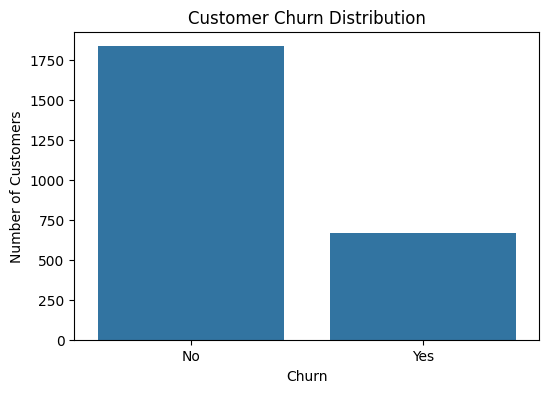

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

**Churn By Contract Type**

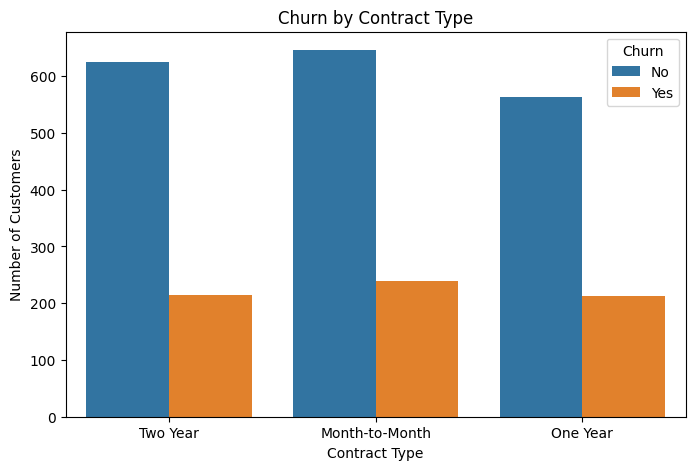

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract_Type",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

**Churn By Internet Service**

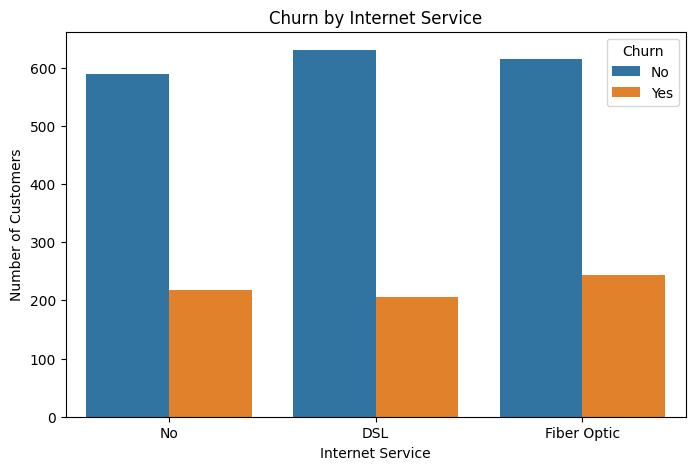

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Internet_Service",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

**Churn By Payment Method**

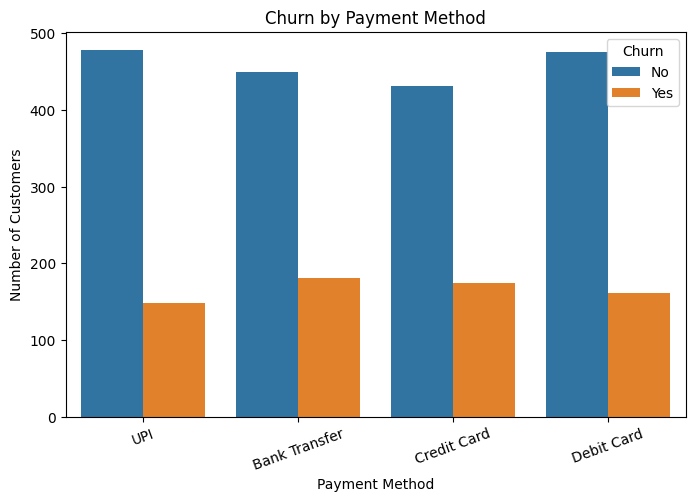

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Churn"
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

**Tenure vs Churn**

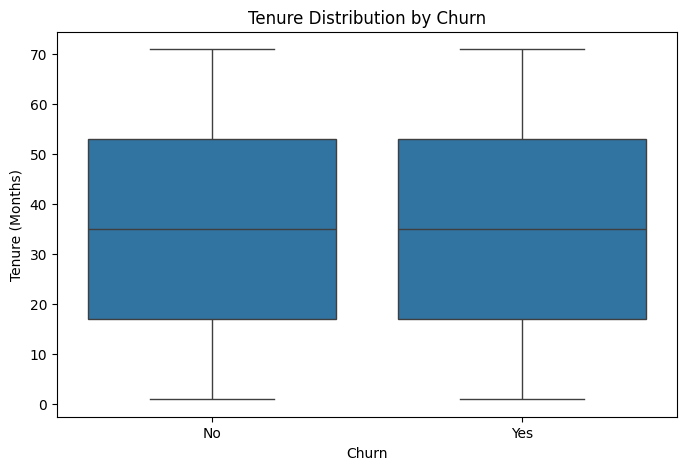

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure_Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

**Monthly Charges vs Churn**

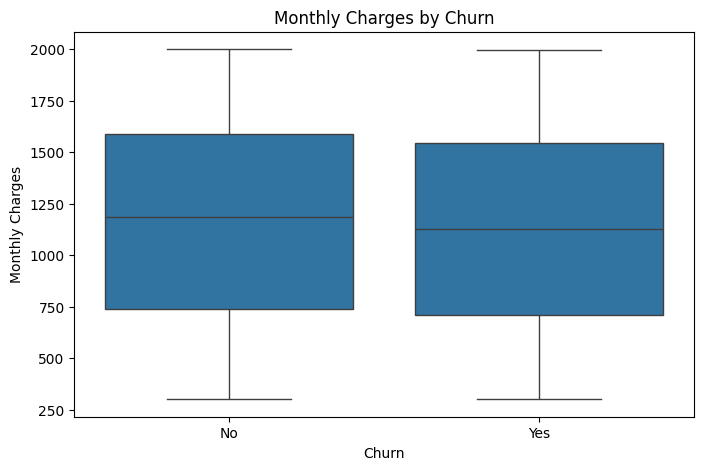

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Monthly_Charges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [24]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [25]:
df["Churn"].value_counts()
#0 means no churn
#1 means churn

,count
Churn,
0,1834
1,666


**Define Futures and Targets**

In [29]:
X = df.drop(columns=["CustomerID", "Churn"])

y = df["Churn"]
X.head()
y.head()

,Churn
0,0
1,0
2,0
3,0
4,0


**Train Test Split**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
numerical_features = [
    "Tenure_Months",
    "Monthly_Charges",
    "Total_Charges"
]

categorical_features = [
    "Contract_Type",
    "Internet_Service",
    "Payment_Method"
]

In [35]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [36]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [37]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

**Use Logistic Regression**

In [40]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [43]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [44]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [45]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", logistic_model)
])

**Train the Model**

In [46]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure_Months',
                                                   'Monthly_Charges',
                                                   'Total_Charges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Contract_Type',
                                                   'Internet_Service',
                                                   'Payment_Method'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

**Make Predictions**

In [48]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

**Evaluate Accuracy**

In [49]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 0.554


**Precision, Recall and F1 Score**

In [50]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Precision: 0.32
Recall: 0.6015
F1 Score: 0.4178


In [51]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.79      0.54      0.64       367
       Churn       0.32      0.60      0.42       133

    accuracy                           0.55       500
   macro avg       0.55      0.57      0.53       500
weighted avg       0.66      0.55      0.58       500



**Confusion Matrix**

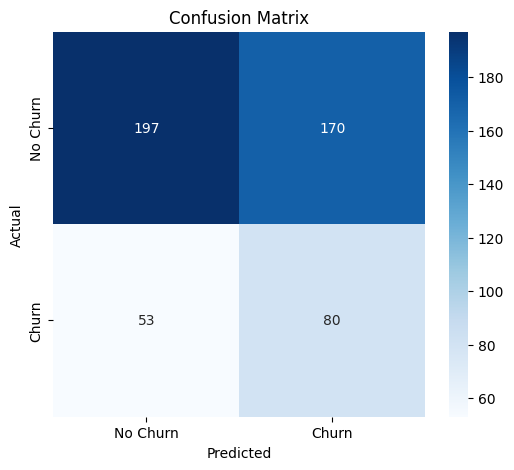

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Future Importance**

In [55]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [56]:
coefficients = model.named_steps[
    "classifier"
].coef_[0]

In [57]:
coefficients = model.named_steps[
    "classifier"
].coef_[0]

In [58]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [61]:
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)
feature_importance.head()

,Feature,Coefficient
9,cat__Payment_Method_Bank Transfer,0.072627
10,cat__Payment_Method_Credit Card,0.065944
7,cat__Internet_Service_Fiber Optic,0.060437
4,cat__Contract_Type_One Year,0.053566
3,cat__Contract_Type_Month-to-Month,0.030815


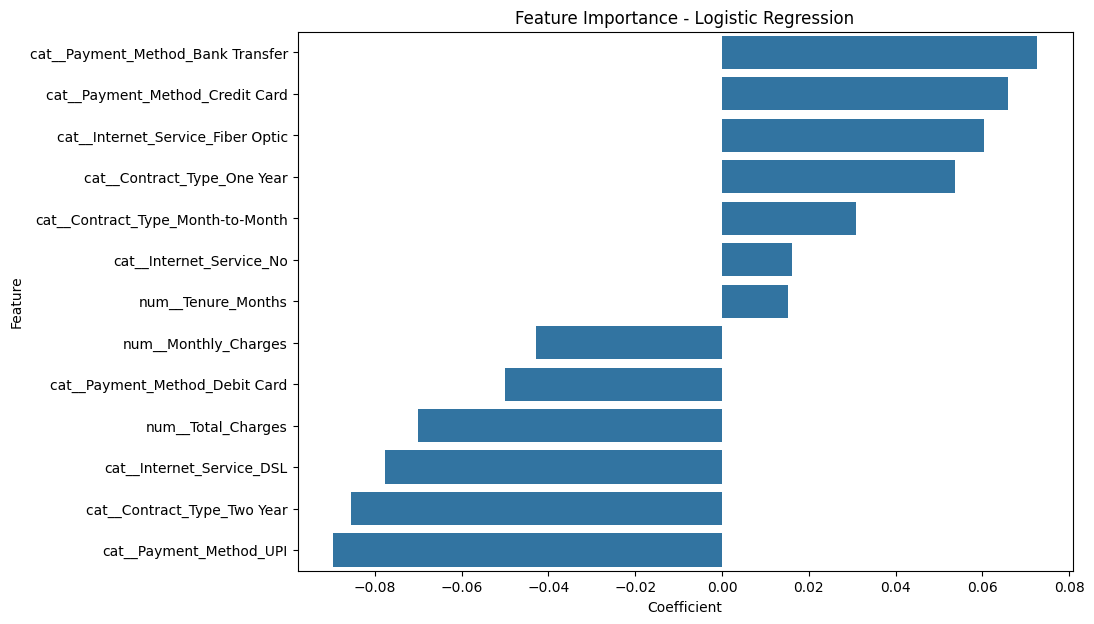

In [62]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

**Predict A New Customer**

In [63]:
new_customer = pd.DataFrame({
    "Tenure_Months": [10],
    "Monthly_Charges": [1500],
    "Total_Charges": [15000],
    "Contract_Type": ["Month-to-Month"],
    "Internet_Service": ["Fiber Optic"],
    "Payment_Method": ["Credit Card"]
})

In [64]:
prediction = model.predict(new_customer)

probability = model.predict_proba(new_customer)[0][1]

In [65]:
if prediction[0] == 1:
    print("Prediction: Customer is likely to churn")
else:
    print("Prediction: Customer is unlikely to churn")

print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: Customer is likely to churn
Churn Probability: 54.78 %


**Final Summary**

In [68]:
print("Customer Churn Prediction Model")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Customer Churn Prediction Model
--------------------------------
Accuracy : 0.554
Precision: 0.32
Recall   : 0.6015
F1 Score : 0.4178
